In [2]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm

In [3]:
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

In [4]:
# --- FUNCIONES DE DAÑO ---

def update_damage_matrix(h_matrix, adjacency_matrix):
    edges = np.argwhere(adjacency_matrix > 0)
    h_values = np.array([h_matrix[i, j] for i, j in edges])
    prob = h_values / np.sum(h_values)
    idx = np.random.choice(len(edges), p=prob)
    h_matrix[edges[idx][0], edges[idx][1]] += 1
    return h_matrix

def get_omega_matrix(h_matrix, adjacency_matrix, alpha):
    return (h_matrix.astype(float) ** (-alpha)) * adjacency_matrix

# --- FUNCIONES DE CALCULO DE AUTOVALORES ---

def Laplaciano(M):
    S = M.sum(axis=1)

    # Construir el Laplaciano: L = diag(S) - M
    # np.diag(S) crea la matriz con S_i en la diagonal principal (S_i * delta_ij)
    L = np.diag(S) - M

    return L

def get_second_eigenvalue_real(M):

    L = Laplaciano(M)

    #Calcular autovalores
    evals = np.linalg.eigvals(L)

    # Extraer partes reales y ordenar
    real_parts = np.sort(np.real(evals))

    # Retornamos el segundo autovalor
    return real_parts[1]

# --- FUNCIONES DE SINCRONIZACIÓN ---

def evolucion_fases(M, t, theta_0):
    """
    Calcula la evolución de las fases de cada nodo en el tiempo t.
    M: Matriz de acoplamiento (Omega)
    t: Escalar o array de tiempos
    theta_0: Vector de fases iniciales (condiciones iniciales)
    """
    L = Laplaciano(M)

    # Si t es un solo valor (escalar)
    if np.isscalar(t):
        matriz_evolucion = expm(-t * L)
        return matriz_evolucion @ theta_0

    # Si t es un array de tiempos, calculamos la fase para cada paso
    else:
        fases_historial = []
        for ti in t:
            matriz_evolucion = expm(-ti * L)
            fases_historial.append(matriz_evolucion @ theta_0)
        return np.array(fases_historial)

def order_parameter_evolucion(fases_t):
    return np.array([np.abs(np.mean(np.exp(1j * f))) for f in fases_t])

# --- FUNCIONES DE SIMULACION ---

def Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t=False):
    """
    Realiza una simulación completa de daño para un alpha dado.
    Retorna la funcionalidad y los parámetros de orden en T=0, 1000 y 10000.
    """
    N = A.shape[0]
    h = np.ones((N, N))
    funcionalidad_local = np.zeros(T_max + 1)

    # Variables para capturar r(t)
    r_t_0, r_t_1000, r_t_10000 = None, None, None
    tau_0 = None

    for T_step in range(T_max + 1):
        Omega = get_omega_matrix(h, A, alpha)
        xi2 = get_second_eigenvalue_real(Omega)

        
        tau_T = 1.0 / xi2 

        if T_step == 0:
            tau_0 = tau_T
            if calcular_r_t:
                r_t_0 = order_parameter_evolucion(evolucion_fases(Omega, tiempos, theta_0))
        elif calcular_r_t and T_step == 1000:
            r_t_1000 = order_parameter_evolucion(evolucion_fases(Omega, tiempos, theta_0))
        elif calcular_r_t and T_step == 10000:
            r_t_10000 = order_parameter_evolucion(evolucion_fases(Omega, tiempos, theta_0))

        funcionalidad_local[T_step] = tau_0 / tau_T
        h = update_damage_matrix(h, A)

    return funcionalidad_local, r_t_0, r_t_1000, r_t_10000, Omega




## RUEDA


>>> Procesando Alpha = 0.25...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.30...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.35...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.40...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.45...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.50...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.55...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.60...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.65...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.70...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.75...
    Simulación 100/100 lista.

--- Tiempo total: 5761.74 segundos ---


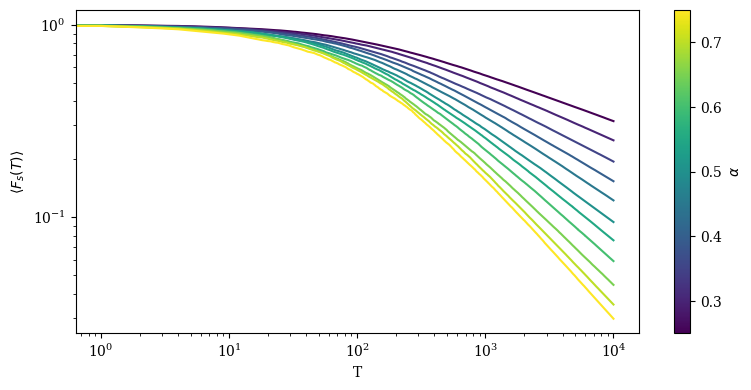

In [5]:
# --- PARÁMETROS ---
num_simulations = 100  # Número de simulaciones por cada alpha
alphas = np.arange(0.25, 0.8, 0.05)
T_max = 10000
t_max_sync = 20
N = 20
G =  nx.wheel_graph(N) 
A = nx.to_numpy_array(G)
tiempos = np.linspace(0, t_max_sync, 1000)


# Diccionario para guardar los resultados de funcionalidad de cada alpha
resultados_funcionalidad = {}

start_time_total = time.time()

# --- BUCLE DE ALPHAS ---
for alpha in alphas:
    print(f"\n>>> Procesando Alpha = {alpha:.2f}...")

    # Reiniciar acumuladores para este alpha específico
    avg_funcionalidad = np.zeros(T_max + 1)
    avg_r_t0 = np.zeros(len(tiempos))
    avg_r_t1000 = np.zeros(len(tiempos))
    avg_r_t10000 = np.zeros(len(tiempos))

    # --- BUCLE DE SIMULACIONES ---
    for sim in range(num_simulations):
        # Generar nuevas fases iniciales para cada simulación
        theta_0 = np.random.uniform(0, 2*np.pi, N)

        if len(alphas)==1:
            calcular_r_t = True
            f_local, r0, r1000, r10000, Omega_final = Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t)
            avg_r_t0 += r0
            avg_r_t1000 += r1000
            avg_r_t10000 += r10000
        else:
            calcular_r_t = False
            f_local, _, _, _, _ = Simulacion(A, alpha, T_max, tiempos, theta_0, False)

        # Acumular resultados de funcionalidad
        avg_funcionalidad += f_local
        # ------------------------------------------------------

    # Promedio final para este alpha y guardado en el diccionario
    resultados_funcionalidad[alpha] = avg_funcionalidad / num_simulations

    # Imprime el progreso
    if (sim + 1) % 5 == 0:
        print(f"    Simulación {sim+1}/{num_simulations} lista.")

print(f"\n--- Tiempo total: {time.time() - start_time_total:.2f} segundos ---")

# --- 5. GRÁFICA MULTI-ALPHA ---
plt.figure(figsize=(8, 4))
colormap = plt.colormaps.get_cmap('viridis')
norm = plt.Normalize(vmin=min(alphas), vmax=max(alphas))

for alpha in sorted(resultados_funcionalidad.keys()):
    color = colormap(norm(alpha))
    plt.loglog(range(T_max + 1), resultados_funcionalidad[alpha],
               color=color, label=f'$\\alpha = {alpha:.2f}$', linewidth=1.5)

# Configuración estética
plt.xlabel("T")
plt.ylabel(r"$\left<F_s(T)\right>$")

# Barra de color
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\alpha$')

plt.tight_layout()
plt.show()

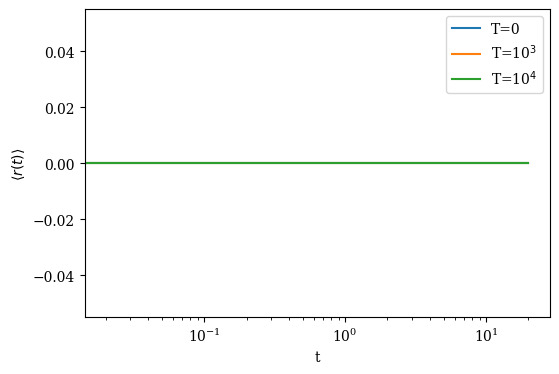

In [6]:
plt.figure(figsize=(6, 4))
plt.semilogx(tiempos,avg_r_t0, label="T=0")
plt.semilogx(tiempos,avg_r_t1000, label=r"T=10$^3$")
plt.semilogx(tiempos,avg_r_t10000, label=r"T=10$^4$")
plt.xlabel("t")
plt.ylabel(r"$\left<r(t)\right>$")
plt.legend()


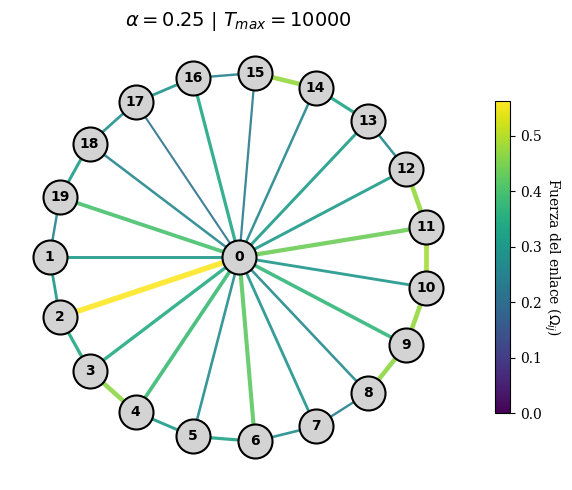

In [37]:
# --- 6. GRÁFICA DE LA RED DAÑADA (CON COLORES Y GROSORES) ---

plt.figure(figsize=(6, 5))

# 1. Definir posiciones organizadas (Shell Layout)
shells = [[0], list(range(1, N))]
pos = nx.shell_layout(G, shells)

# 2. Extraer información de enlaces
edges = list(G.edges())
weights = np.array([Omega_final[u, v] for u, v in edges])

# Normalizamos los pesos para el color (0 a 1) para que el mapa de color funcione bien
if weights.max() > 0:
    weights_norm = (weights - weights.min()) / (weights.max() - weights.min())
else:
    weights_norm = weights

# 3. Dibujar la red
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightgray', 
                       edgecolors='black', linewidths=1.5)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Usamos el mapa de color 'autumn' o 'inferno' para resaltar el daño
# 'Wistia' o 'RdYlGn' también son buenas opciones
edge_colors = weights # El color depende directamente del peso

nodes = nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges, 
    width=weights * 7,           # El grosor depende del peso (ajusta el factor 7)
    edge_color=edge_colors,     # El color depende del peso
    edge_cmap=plt.cm.viridis,    # Colormap
    alpha=0.9,
    edge_vmin=0, 
    edge_vmax=weights.max() if len(weights) > 0 else 1
)

# 4. Añadir una barra de color para entender los enlaces
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(vmin=0, vmax=weights.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.7)
cbar.set_label(r'Fuerza del enlace ($\Omega_{ij}$)', rotation=270, labelpad=15)

plt.title(f"$\\alpha={alpha:.2f}$ | $T_{{max}}={T_max}$", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## ERDOS-RENYI


>>> Procesando Alpha = 0.25...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.30...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.35...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.40...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.45...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.50...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.55...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.60...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.65...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.70...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.75...
    Simulación 100/100 lista.

--- Tiempo total: 7027.71 segundos ---


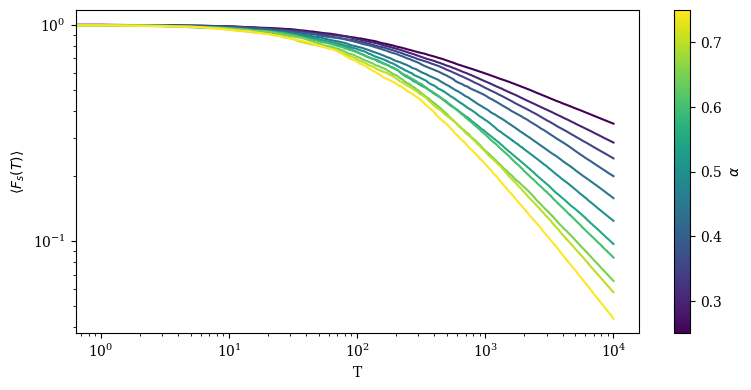

In [7]:
# --- PARÁMETROS ---
num_simulations = 100  # Número de simulaciones por cada alpha
alphas = np.arange(0.25, 0.8, 0.05)
T_max = 10000
t_max_sync = 20
N = 20
G = nx.erdos_renyi_graph(N, p=0.3)
A = nx.to_numpy_array(G)
tiempos = np.linspace(0, t_max_sync, 1000)


# Diccionario para guardar los resultados de funcionalidad de cada alpha
resultados_funcionalidad = {}

start_time_total = time.time()

# --- BUCLE DE ALPHAS ---
for alpha in alphas:
    print(f"\n>>> Procesando Alpha = {alpha:.2f}...")

    # Reiniciar acumuladores para este alpha específico
    avg_funcionalidad = np.zeros(T_max + 1)
    avg_r_t0 = np.zeros(len(tiempos))
    avg_r_t1000 = np.zeros(len(tiempos))
    avg_r_t10000 = np.zeros(len(tiempos))

    # --- BUCLE DE SIMULACIONES ---
    for sim in range(num_simulations):
        # Generar nuevas fases iniciales para cada simulación
        theta_0 = np.random.uniform(0, 2*np.pi, N)

        if len(alphas)==1:
            calcular_r_t = True
            f_local, r0, r1000, r10000, Omega_final = Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t)
            avg_r_t0 += r0
            avg_r_t1000 += r1000
            avg_r_t10000 += r10000
        else:
            calcular_r_t = False
            f_local, _, _, _, _ = Simulacion(A, alpha, T_max, tiempos, theta_0, False)

        # Acumular resultados de funcionalidad
        avg_funcionalidad += f_local
        # ------------------------------------------------------

    # Promedio final para este alpha y guardado en el diccionario
    resultados_funcionalidad[alpha] = avg_funcionalidad / num_simulations

    # Imprime el progreso
    if (sim + 1) % 5 == 0:
        print(f"    Simulación {sim+1}/{num_simulations} lista.")

print(f"\n--- Tiempo total: {time.time() - start_time_total:.2f} segundos ---")

# --- 5. GRÁFICA MULTI-ALPHA ---
plt.figure(figsize=(8, 4))
colormap = plt.colormaps.get_cmap('viridis')
norm = plt.Normalize(vmin=min(alphas), vmax=max(alphas))

for alpha in sorted(resultados_funcionalidad.keys()):
    color = colormap(norm(alpha))
    plt.loglog(range(T_max + 1), resultados_funcionalidad[alpha],
               color=color, label=f'$\\alpha = {alpha:.2f}$', linewidth=1.5)

# Configuración estética
plt.xlabel("T")
plt.ylabel(r"$\left<F_s(T)\right>$")

# Barra de color
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\alpha$')

plt.tight_layout()
plt.show()

## BARABASI-ALBERT


>>> Procesando Alpha = 0.25...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.30...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.35...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.40...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.45...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.50...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.55...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.60...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.65...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.70...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.75...
    Simulación 100/100 lista.

--- Tiempo total: 5887.97 segundos ---


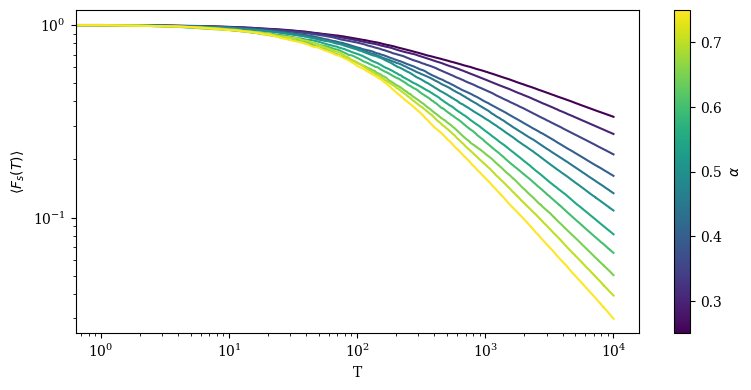

In [8]:
# --- PARÁMETROS ---
num_simulations = 100  # Número de simulaciones por cada alpha
alphas = np.arange(0.25, 0.8, 0.05)
T_max = 10000
t_max_sync = 20
N = 20
G = nx.barabasi_albert_graph(N, m=2)
A = nx.to_numpy_array(G)
tiempos = np.linspace(0, t_max_sync, 1000)


# Diccionario para guardar los resultados de funcionalidad de cada alpha
resultados_funcionalidad = {}

start_time_total = time.time()

# --- BUCLE DE ALPHAS ---
for alpha in alphas:
    print(f"\n>>> Procesando Alpha = {alpha:.2f}...")

    # Reiniciar acumuladores para este alpha específico
    avg_funcionalidad = np.zeros(T_max + 1)
    avg_r_t0 = np.zeros(len(tiempos))
    avg_r_t1000 = np.zeros(len(tiempos))
    avg_r_t10000 = np.zeros(len(tiempos))

    # --- BUCLE DE SIMULACIONES ---
    for sim in range(num_simulations):
        # Generar nuevas fases iniciales para cada simulación
        theta_0 = np.random.uniform(0, 2*np.pi, N)

        if len(alphas)==1:
            calcular_r_t = True
            f_local, r0, r1000, r10000, Omega_final = Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t)
            avg_r_t0 += r0
            avg_r_t1000 += r1000
            avg_r_t10000 += r10000
        else:
            calcular_r_t = False
            f_local, _, _, _, _ = Simulacion(A, alpha, T_max, tiempos, theta_0, False)

        # Acumular resultados de funcionalidad
        avg_funcionalidad += f_local
        # ------------------------------------------------------

    # Promedio final para este alpha y guardado en el diccionario
    resultados_funcionalidad[alpha] = avg_funcionalidad / num_simulations

    # Imprime el progreso
    if (sim + 1) % 5 == 0:
        print(f"    Simulación {sim+1}/{num_simulations} lista.")

print(f"\n--- Tiempo total: {time.time() - start_time_total:.2f} segundos ---")

# --- 5. GRÁFICA MULTI-ALPHA ---
plt.figure(figsize=(8, 4))
colormap = plt.colormaps.get_cmap('viridis')
norm = plt.Normalize(vmin=min(alphas), vmax=max(alphas))

for alpha in sorted(resultados_funcionalidad.keys()):
    color = colormap(norm(alpha))
    plt.loglog(range(T_max + 1), resultados_funcionalidad[alpha],
               color=color, label=f'$\\alpha = {alpha:.2f}$', linewidth=1.5)

# Configuración estética
plt.xlabel("T")
plt.ylabel(r"$\left<F_s(T)\right>$")

# Barra de color
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\alpha$')

plt.tight_layout()
plt.show()

## WATTS-STROGATZ


>>> Procesando Alpha = 0.25...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.30...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.35...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.40...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.45...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.50...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.55...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.60...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.65...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.70...
    Simulación 100/100 lista.

>>> Procesando Alpha = 0.75...
    Simulación 100/100 lista.

--- Tiempo total: 6608.45 segundos ---


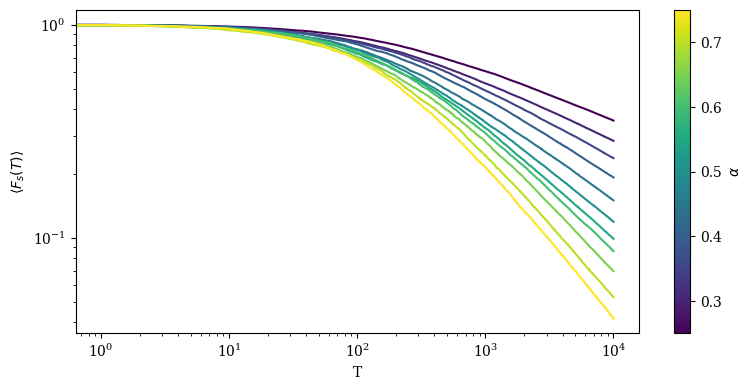

In [9]:
# --- PARÁMETROS ---
num_simulations = 100  # Número de simulaciones por cada alpha
alphas = np.arange(0.25, 0.8, 0.05)
T_max = 10000
t_max_sync = 20
N = 20
G = nx.watts_strogatz_graph(N, k=4, p=0.1)
A = nx.to_numpy_array(G)
tiempos = np.linspace(0, t_max_sync, 1000)


# Diccionario para guardar los resultados de funcionalidad de cada alpha
resultados_funcionalidad = {}

start_time_total = time.time()

# --- BUCLE DE ALPHAS ---
for alpha in alphas:
    print(f"\n>>> Procesando Alpha = {alpha:.2f}...")

    # Reiniciar acumuladores para este alpha específico
    avg_funcionalidad = np.zeros(T_max + 1)
    avg_r_t0 = np.zeros(len(tiempos))
    avg_r_t1000 = np.zeros(len(tiempos))
    avg_r_t10000 = np.zeros(len(tiempos))

    # --- BUCLE DE SIMULACIONES ---
    for sim in range(num_simulations):
        # Generar nuevas fases iniciales para cada simulación
        theta_0 = np.random.uniform(0, 2*np.pi, N)

        if len(alphas)==1:
            calcular_r_t = True
            f_local, r0, r1000, r10000, Omega_final = Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t)
            avg_r_t0 += r0
            avg_r_t1000 += r1000
            avg_r_t10000 += r10000
        else:
            calcular_r_t = False
            f_local, _, _, _, _ = Simulacion(A, alpha, T_max, tiempos, theta_0, False)

        # Acumular resultados de funcionalidad
        avg_funcionalidad += f_local
        # ------------------------------------------------------

    # Promedio final para este alpha y guardado en el diccionario
    resultados_funcionalidad[alpha] = avg_funcionalidad / num_simulations

    # Imprime el progreso
    if (sim + 1) % 5 == 0:
        print(f"    Simulación {sim+1}/{num_simulations} lista.")

print(f"\n--- Tiempo total: {time.time() - start_time_total:.2f} segundos ---")

# --- 5. GRÁFICA MULTI-ALPHA ---
plt.figure(figsize=(8, 4))
colormap = plt.colormaps.get_cmap('viridis')
norm = plt.Normalize(vmin=min(alphas), vmax=max(alphas))

for alpha in sorted(resultados_funcionalidad.keys()):
    color = colormap(norm(alpha))
    plt.loglog(range(T_max + 1), resultados_funcionalidad[alpha],
               color=color, label=f'$\\alpha = {alpha:.2f}$', linewidth=1.5)

# Configuración estética
plt.xlabel("T")
plt.ylabel(r"$\left<F_s(T)\right>$")

# Barra de color
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\alpha$')

plt.tight_layout()
plt.show()

## ANÁLISIS DEL DATA SET

In [4]:
dataset_g6 = [
    "E?Bw", "E?bo", "E?bw", "E?ow", "E?qo", "E?qw", "E?ro", "E?rw", "E?zO", "E?zW",
    "E?zo", "E?zw", "E?~o", "E?~w", "ECR_", "ECRo", "ECRw", "ECYW", "ECZ?", "ECZG",
    "ECZO", "ECZW", "ECZ_", "ECZg", "ECZo", "ECZw", "ECfo", "ECfw", "ECpo", "ECqg",
    "ECr_", "ECrg", "ECro", "ECrw", "ECuw", "ECvo", "ECvw", "ECxo", "ECxw", "ECzW",
    "ECzg", "ECzo", "ECzw", "EC~o", "EC~w", "EEhW", "EEh_", "EEho", "EEhw", "EEiW",
    "EEio", "EEjW", "EEj_", "EEjo", "EEjw", "EElw", "EEno", "EEnw", "EEr_", "EEro",
    "EErw", "EEuw", "EEvo", "EEvw", "EEzO", "EEz_", "EEzg", "EEzo", "EEzw", "EE~w",
    "EFzW", "EFz_", "EFzo", "EFzw", "EF~w", "EQjO", "EQj_", "EQjg", "EQjo", "EQjw",
    "EQyw", "EQzO", "EQzW", "EQzg", "EQzo", "EQzw", "EQ~o", "EQ~w", "ETno", "ETnw",
    "ETzg", "ETzo", "ETzw", "ET~w", "EUZO", "EUZ_", "EUZo", "EUZw", "EUxo", "EUzW",
    "EUzo", "EUzw", "EU~w", "EV~w", "E]yw", "E]zg", "E]zo", "E]zw", "E]~o", "E]~w",
    "E^~w", "E~~w"
]

lista_grafos = [nx.from_graph6_bytes(g.encode()) for g in dataset_g6]

>>> Iniciando Simulaciones para grafo número 0...
>>> Iniciando Simulaciones para grafo número 1...
>>> Iniciando Simulaciones para grafo número 2...
>>> Iniciando Simulaciones para grafo número 3...
>>> Iniciando Simulaciones para grafo número 4...
>>> Iniciando Simulaciones para grafo número 5...
>>> Iniciando Simulaciones para grafo número 6...
>>> Iniciando Simulaciones para grafo número 7...
>>> Iniciando Simulaciones para grafo número 8...
>>> Iniciando Simulaciones para grafo número 9...
>>> Iniciando Simulaciones para grafo número 10...
>>> Iniciando Simulaciones para grafo número 11...
>>> Iniciando Simulaciones para grafo número 12...
>>> Iniciando Simulaciones para grafo número 13...
>>> Iniciando Simulaciones para grafo número 14...
>>> Iniciando Simulaciones para grafo número 15...
>>> Iniciando Simulaciones para grafo número 16...
>>> Iniciando Simulaciones para grafo número 17...
>>> Iniciando Simulaciones para grafo número 18...
>>> Iniciando Simulaciones para grafo núm

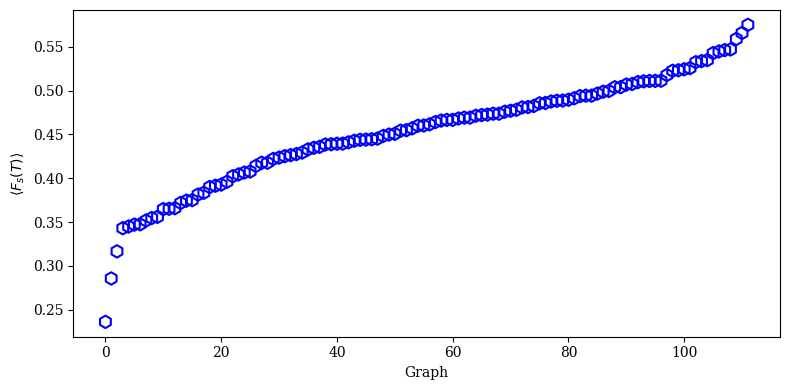

In [ ]:
# --- PARÁMETROS ---
num_simulations = 1000
alpha = 0.5           
T_max = 100
t_max_sync = 20
tiempos = np.linspace(0, t_max_sync, 1000)

Num_G = np.arange(0,len(lista_grafos))
avg_funcionalidad_G = np.zeros(len(lista_grafos))



start_time_total = time.time()
for i in Num_G:
    avg_funcionalidad = np.zeros(T_max + 1)
    G = lista_grafos[i]
    A = nx.to_numpy_array(G)


    print(f">>> Iniciando Simulaciones para grafo número {Num_G[i]}...")

    # --- BUCLE DE SIMULACIONES ---
    for sim in range(num_simulations):
        # Generar nuevas fases iniciales para cada simulación
        theta_0 = np.random.uniform(0, 2*np.pi, len(G))

        # funcionalidad, r0, r1000, r10000, Omega_final
        f_local, _, _, _, _ = Simulacion(A, alpha, T_max, tiempos, theta_0, calcular_r_t=False)

        # Acumular resultados
        avg_funcionalidad += f_local


    # --- PROMEDIADO FINAL ---
    avg_funcionalidad /= num_simulations
    avg_funcionalidad_G[i] = avg_funcionalidad[-1]

print(f"\n--- Tiempo total: {((time.time() - start_time_total)/60):.2f} minutos ---")

avg_funcionalidad_G_Ordenadas = np.sort(avg_funcionalidad_G)

# --- 5. GRÁFICA DE FUNCIONALIDAD ---
plt.figure(figsize=(8, 4))
plt.scatter(Num_G, avg_funcionalidad_G_Ordenadas, facecolors='none', edgecolors='blue', linewidth=1.5, marker='h', s=80,)
plt.xlabel("Graph")
plt.ylabel(r"$\langle F_s(T) \rangle$")
plt.tight_layout()
plt.show()

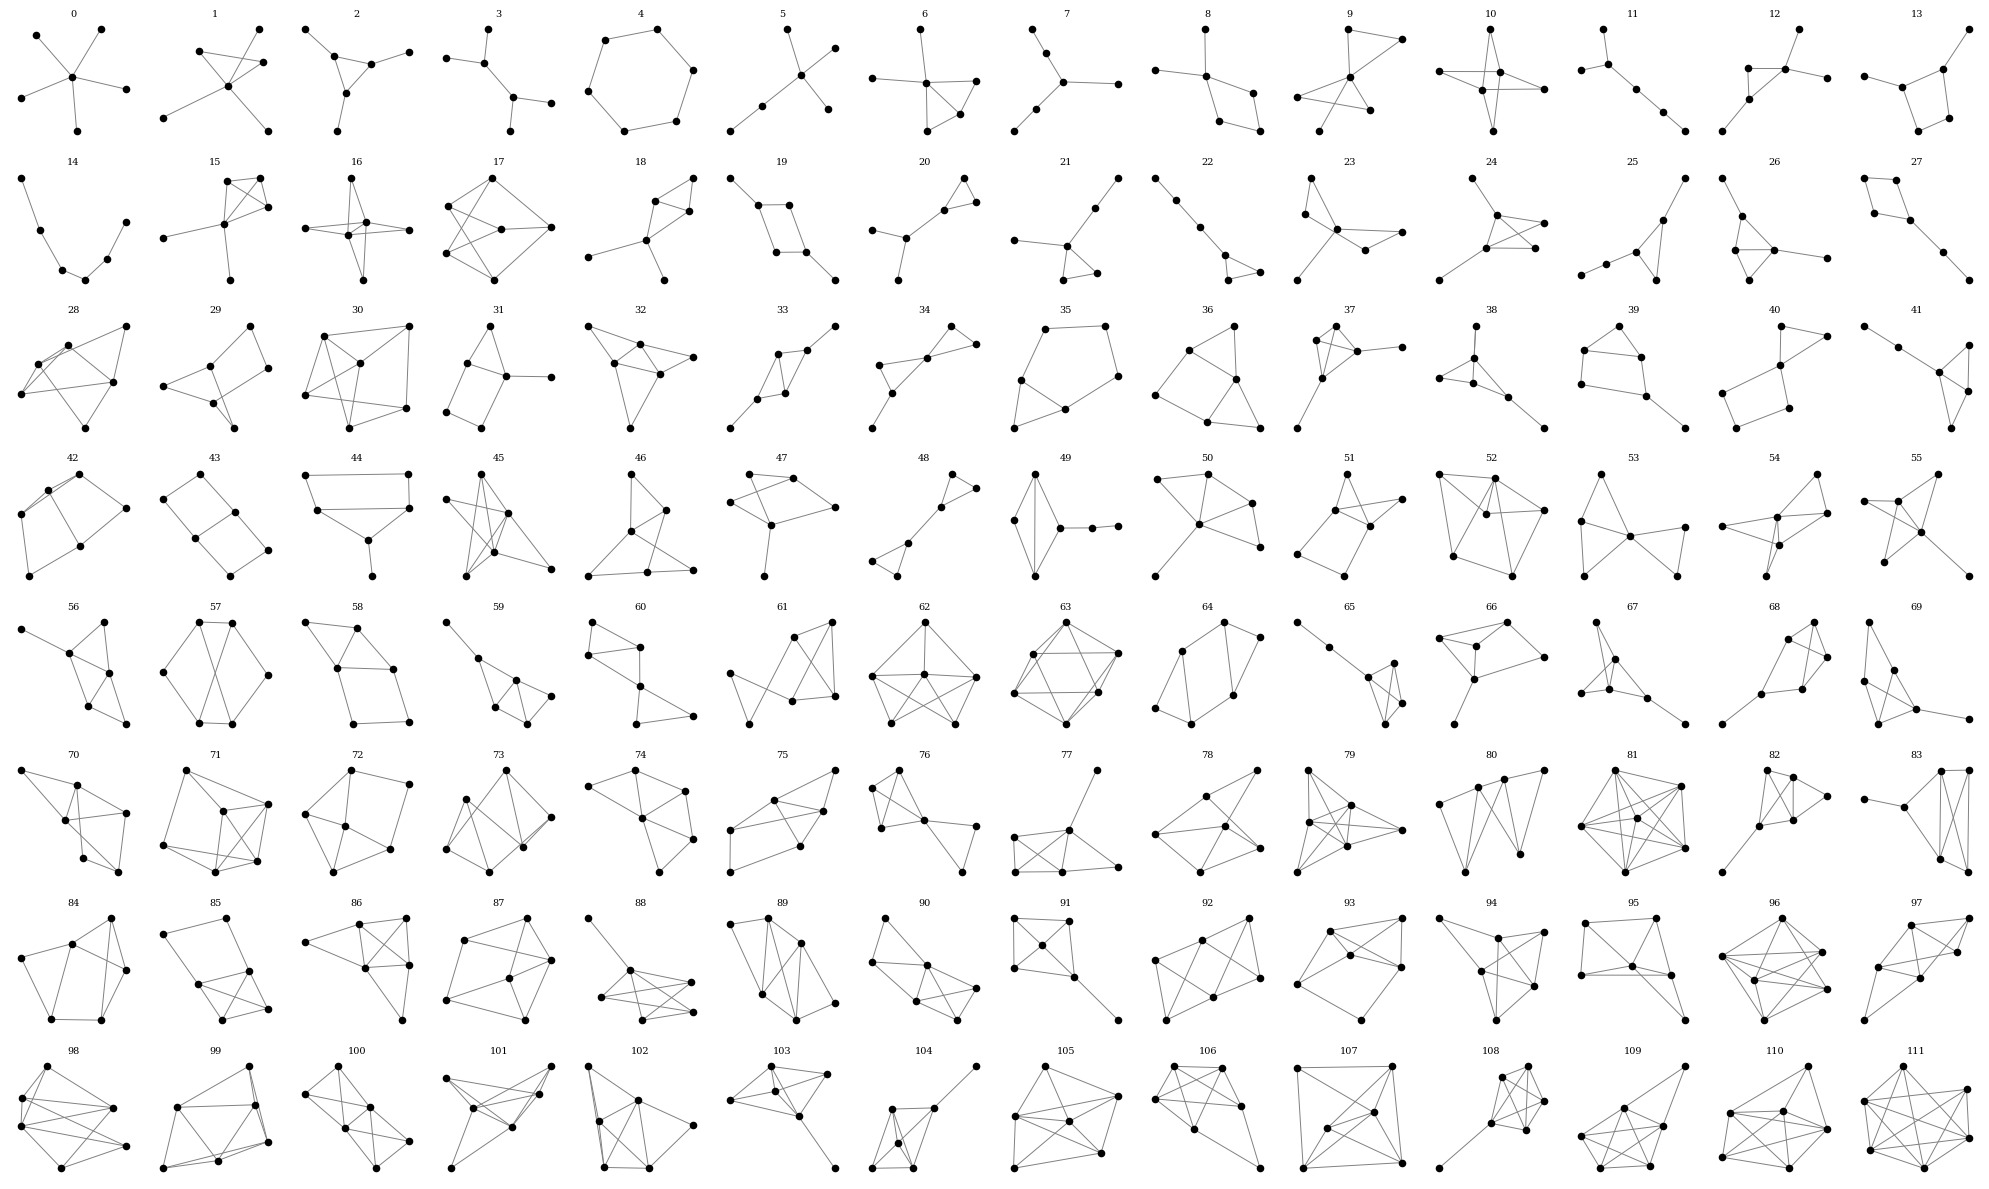

In [ ]:
G_ordenado= np.argsort(avg_funcionalidad_G)
# 1. Configurar la cuadrícula
rows = 8
cols = 14
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes_flat = axes.flatten()

# 3. Iterar sobre los índices ORDENADOS
for ranking_pos, original_idx in enumerate(G_ordenado):
    ax = axes_flat[ranking_pos]

    # Seleccionamos el grafo según el ranking
    G = lista_grafos[original_idx]

    # Dibujar el grafo
    pos = nx.spring_layout(G)
    nx.draw(G, pos,
            ax=ax,
            node_size=20,
            node_color='black',
            edge_color='gray',
            width=0.7)

    ax.set_title(f"{ranking_pos}", fontsize=7, pad=2)
    ax.axis('off')

# 4. Ajustar espacio
plt.tight_layout()
plt.show()

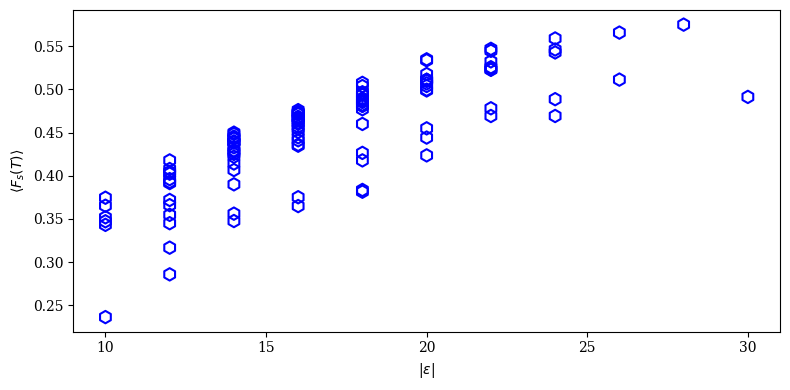

In [12]:
edges_G = 2*np.array([G.number_of_edges() for G in lista_grafos])

# --- 5. GRÁFICA DE FUNCIONALIDAD ---
plt.figure(figsize=(8, 4))
plt.scatter(edges_G, avg_funcionalidad_G, facecolors='none', edgecolors='blue', linewidth=1.5, marker='h', s=80)

# Definir el rango de 10 a 30 con pasos de 5
# Usamos 31 porque el límite superior de np.arange no es inclusivo
plt.xticks(np.arange(10, 31, 5))

# También limitamos el área visible del gráfico para que coincida con ese rango
plt.xlim(9, 31)

plt.xlabel(r"|$\varepsilon$|")
plt.ylabel(r"$\langle F_s(T) \rangle$")
plt.tight_layout()
plt.show()